#### 1. Загрузка данных

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid")

In [22]:
import pandas as pd

data_path = "../data"

users = pd.read_csv(
    f"{data_path}/users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

movies = pd.read_csv(
    f"{data_path}/movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movie_id", "title", "genres"]
)

ratings = pd.read_csv(
    f"{data_path}/ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

In [23]:
users.head(), movies.head(), ratings.head()

(   user_id gender  age  occupation zip_code
 0        1      F    1          10    48067
 1        2      M   56          16    70072
 2        3      M   25          15    55117
 3        4      M   45           7    02460
 4        5      M   25          20    55455,
    movie_id                               title                        genres
 0         1                    Toy Story (1995)   Animation|Children's|Comedy
 1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
 2         3             Grumpier Old Men (1995)                Comedy|Romance
 3         4            Waiting to Exhale (1995)                  Comedy|Drama
 4         5  Father of the Bride Part II (1995)                        Comedy,
    user_id  movie_id  rating  timestamp
 0        1      1193       5  978300760
 1        1       661       3  978302109
 2        1       914       3  978301968
 3        1      3408       4  978300275
 4        1      2355       5  978824291)

In [24]:
ratings.shape, users.shape, movies.shape

((1000209, 4), (6040, 5), (3883, 3))

#### 2. Проверка пропусков и дубликатов

In [25]:
print("Пропуски в users:")
display(users.isna().sum())

print("\nПропуски в movies:")
display(movies.isna().sum())

print("\nПропуски в ratings:")
display(ratings.isna().sum())

print("\nДубликаты в ratings:", ratings.duplicated().sum())

Пропуски в users:


user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64


Пропуски в movies:


movie_id    0
title       0
genres      0
dtype: int64


Пропуски в ratings:


user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


Дубликаты в ratings: 0


В датасете нет пропусков и дубликатов, данные чистые.

#### 3. Анализ распределение рейтинов

In [26]:
ratings['rating'].describe()

count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

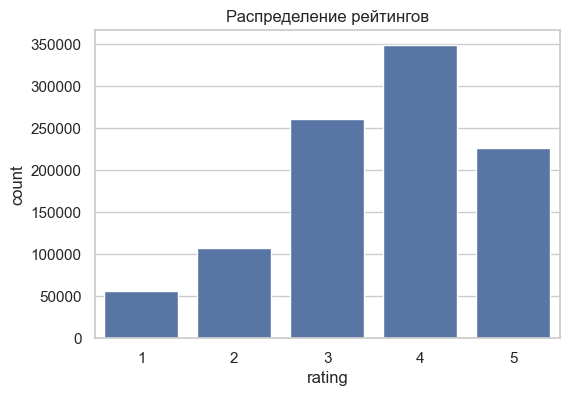

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=ratings)
plt.title("Распределение рейтингов")
plt.show()

Диапазон рейтингов от 1 до 5, самая популярная оценка - 4

#### 4. Активность пользователей

In [28]:
user_activity = ratings.groupby("user_id").size().rename("n_ratings").reset_index()

user_activity.describe()

,user_id,n_ratings
count,6040.000000,6040.000000
mean,3020.500000,165.597517
std,1743.742145,192.747029
min,1.000000,20.000000
25%,1510.750000,44.000000
50%,3020.500000,96.000000
75%,4530.250000,208.000000
max,6040.000000,2314.000000


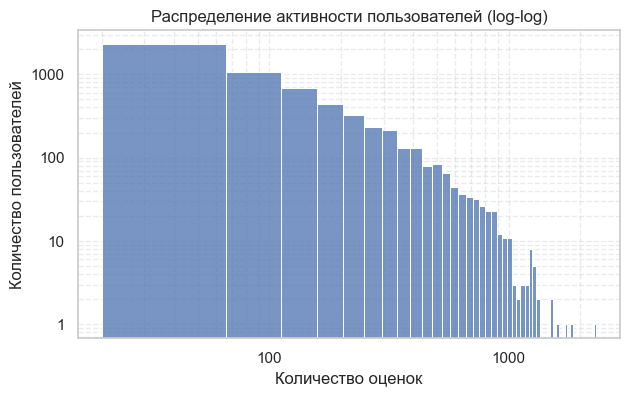

In [29]:
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(7,4))
sns.histplot(user_activity["n_ratings"], bins=50)
plt.xscale("log")
plt.yscale("log")
plt.title("Распределение активности пользователей (log-log)")
plt.xlabel("Количество оценок")
plt.ylabel("Количество пользователей")
plt.grid(True, which="both", linestyle="--", alpha=0.4)

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())

plt.show()

Распределение количества оценок на пользователя имеет heavy-tail структуру: большинство пользователей ставят очень мало оценок, а небольшая группа ставит тысячи. Это типично для рекомендательных систем и приводит к проблеме холодного старта.

In [30]:
user_activity["n_ratings"].describe(percentiles=[.5, .9, .99, .999])

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
50%        96.000000
90%       400.000000
99%       906.660000
99.9%    1343.181000
max      2314.000000
Name: n_ratings, dtype: float64

#### 5. Популярность фильмов

In [31]:
# количество оценок на фильм
item_activity = (
    ratings.groupby("movie_id")
    .size()
    .rename("n_ratings")
    .reset_index()
)

item_activity.describe()

,movie_id,n_ratings
count,3706.000000,3706.000000
mean,1995.573125,269.889099
std,1151.148045,384.047838
min,1.000000,1.000000
25%,989.250000,33.000000
50%,2033.500000,123.500000
75%,2990.750000,350.000000
max,3952.000000,3428.000000


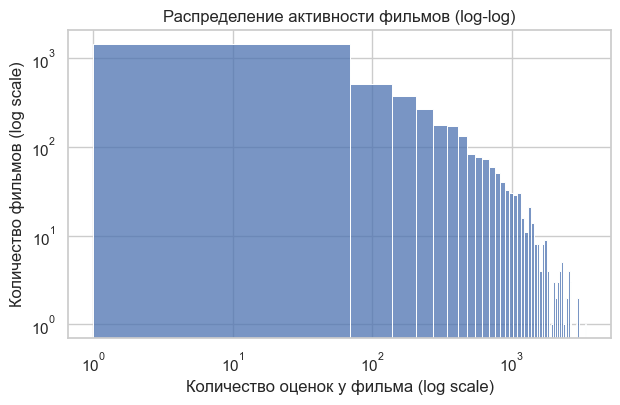

In [32]:
# распределение количества оценок на фильм
item_activity = (
    ratings.groupby("movie_id")
    .size()
    .rename("n_ratings")
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.histplot(item_activity["n_ratings"], bins=50)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Количество оценок у фильма (log scale)")
plt.ylabel("Количество фильмов (log scale)")
plt.title("Распределение активности фильмов (log-log)")
plt.show()

Большинство фильмов имеют очень мало оценок (менее 20), в то время как небольшая группа фильмов собирает сотни и тысячи оценок. Это формирует длинный хвост (long-tail), типичный для рекомендательных систем, и приводит к проблеме холодного старта для фильмов.

#### 6. Распределение оценок

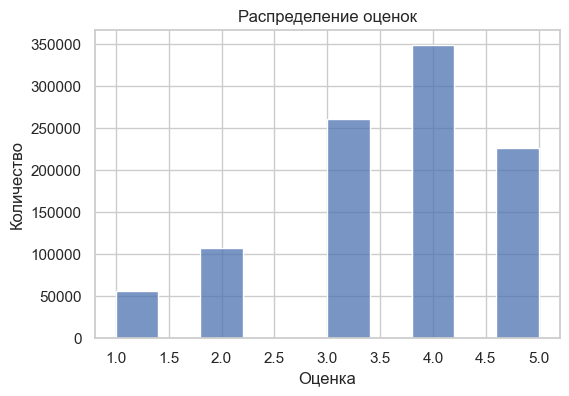

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(ratings["rating"], bins=10, kde=False)
plt.xlabel("Оценка")
plt.ylabel("Количество")
plt.title("Распределение оценок")
plt.show()

In [34]:
ratings["rating"].describe()

count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Распределение оценок имеет смещение в сторону высоких значений: мода на оценке 4.0 и медиана > 3.0. Пользователи ставят мало низких оценок (1–2). Это типичное явление в рекомендательных системах и приводит к отсутствию негативной обратной связи, усложняя обучение моделей и ранжирование.

Это также обосновывает выбор алгоритмов типа implicit feedback (ALS, BPR), вместо чисто supervised.

#### 7. Анализ времени

In [35]:
# переводим timestamp в дату

ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"] = ratings["timestamp"].dt.year
ratings["month"] = ratings["timestamp"].dt.to_period("M")

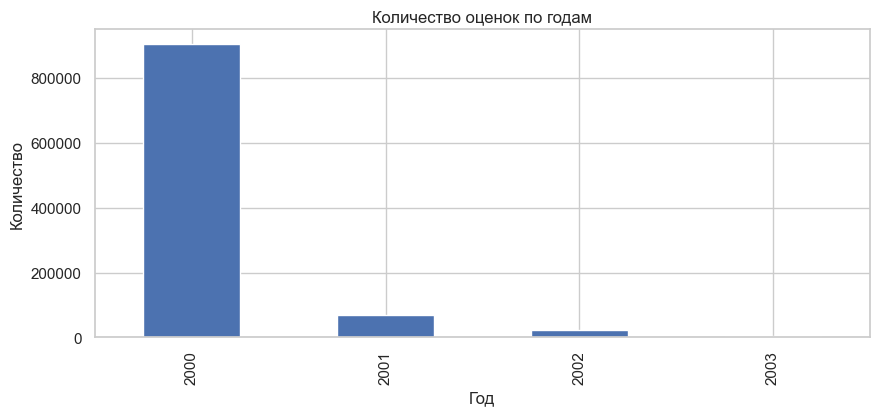

In [36]:
# строим график активности по годам

ratings.groupby("year")["rating"].count().plot(
    kind="bar", figsize=(10,4)
)
plt.title("Количество оценок по годам")
plt.ylabel("Количество")
plt.xlabel("Год")
plt.show()

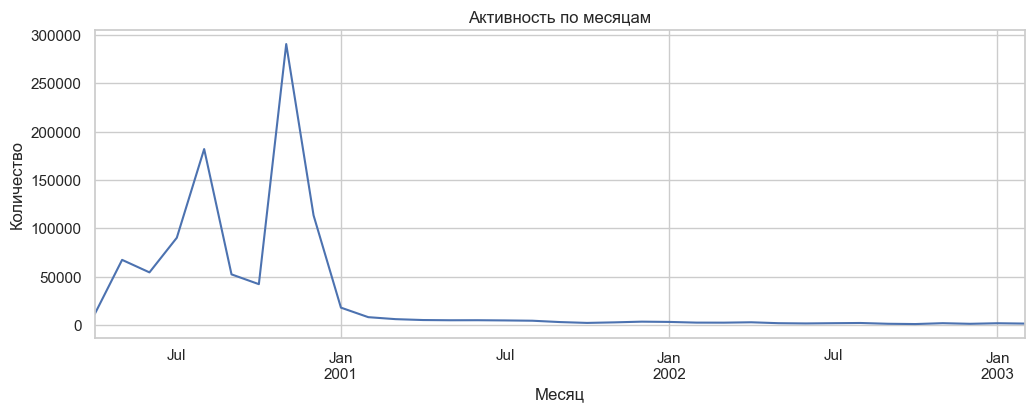

In [37]:
# строим график активности по месяцам

ratings.groupby("month")["rating"].count().plot(
    figsize=(12,4)
)
plt.title("Активность по месяцам")
plt.ylabel("Количество")
plt.xlabel("Месяц")
plt.show()

Активность пользователей меняется во времени. Видна динамика роста данных, а также сезонные колебания. Это важно для моделирования, так как случайный train-test split нарушает временную структуру данных. В проде для recommender systems используют time-based split, иначе происходит data leakage и модель видит будущие предпочтения.

In [42]:
ratings["weekday"] = ratings["timestamp"].dt.day_name()
ratings["hour"] = ratings["timestamp"].dt.hour

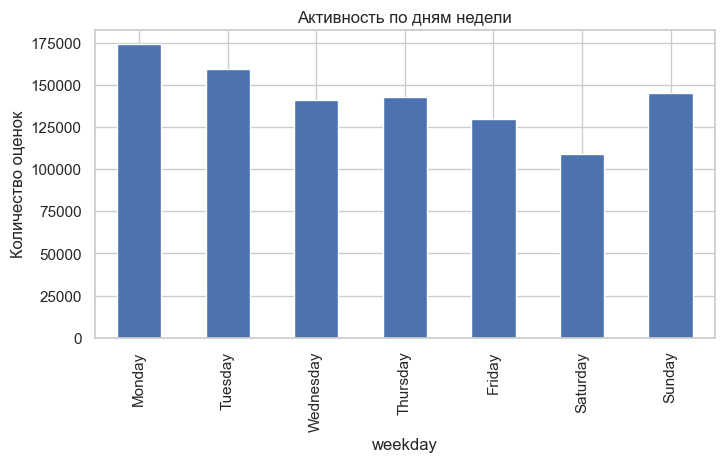

In [43]:
plt.figure(figsize=(8,4))
ratings['weekday'].value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind='bar')
plt.title("Активность по дням недели")
plt.ylabel("Количество оценок")
plt.show()

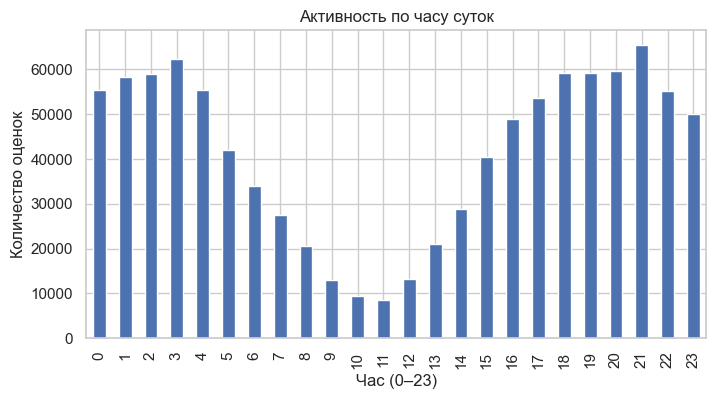

In [44]:
plt.figure(figsize=(8,4))
ratings['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Активность по часу суток")
plt.ylabel("Количество оценок")
plt.xlabel("Час (0–23)")
plt.show()

Пользователи ставят больше оценок в вечернее и ночное время (пики после 18:00) и в выходные дни. Этот паттерн типичен для потребления медиа-контента. Также это подтверждает, что данные неравномерны во времени, что важно учитывать при построении рекоммендаций и при разбиении данных на train/val по времени.

#### 8. Корреляция активности пользоватей и популярности фильмов

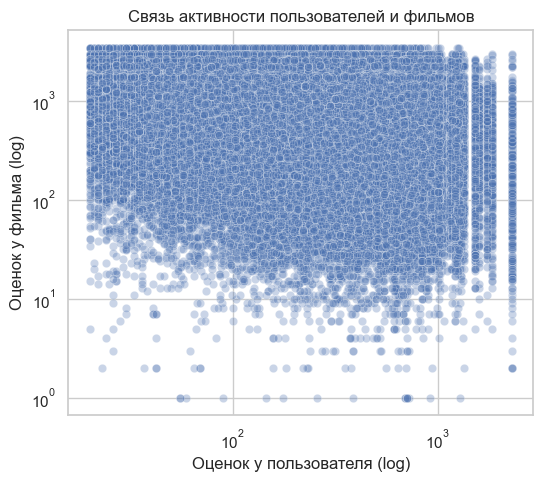

In [45]:
user_activity = ratings.groupby('user_id').size().reset_index(name='user_ratings')
item_activity = ratings.groupby('movie_id').size().reset_index(name='movie_ratings')

df_corr = ratings.merge(user_activity, on='user_id').merge(item_activity, on='movie_id')

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df_corr.sample(150_000, random_state=42),
    x='user_ratings', y='movie_ratings',
    alpha=0.3
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Оценок у пользователя (log)")
plt.ylabel("Оценок у фильма (log)")
plt.title("Связь активности пользователей и фильмов")
plt.show()

Активность пользователя и популярность фильмов не коррелируют напрямую. Это важное свойство, так как система может эффективно обучаться на «длинном хвосте» и не ограничиваться только популярными объектами.

#### 9. Анализ жанров

In [46]:
# кол-во жанров на фильм

movies['genre_count'] = movies['genres'].apply(lambda x: len(x.split('|')))

movies['genre_count'].describe()

count    3883.000000
mean        1.650270
std         0.804589
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: genre_count, dtype: float64

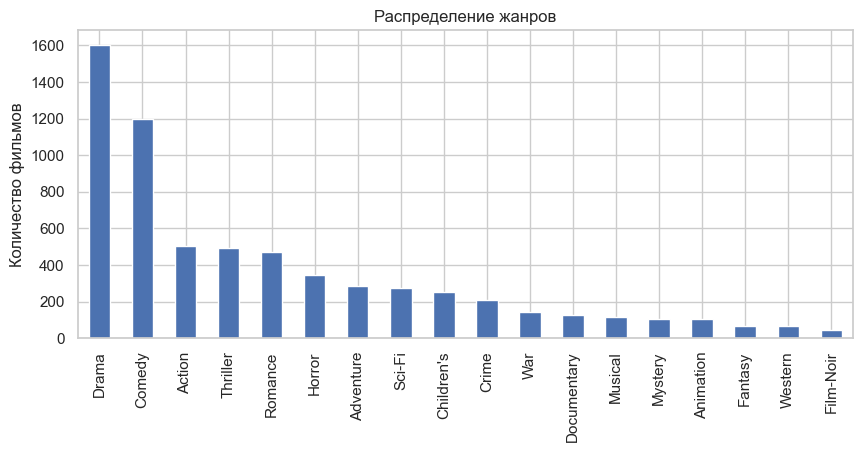

In [47]:
# распределение жанров

from collections import Counter

genre_counter = Counter()

for g in movies['genres']:
    for x in g.split('|'):
        genre_counter[x] += 1

pd.Series(genre_counter).sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Распределение жанров")
plt.ylabel("Количество фильмов")
plt.show()

In [50]:
genre_df = (movies.assign(genre=movies['genres'].str.split('|'))
                     .explode('genre')
                     .merge(ratings, on='movie_id'))

In [53]:
# топ по кол-ву оценок

genre_df.groupby('genre').size().sort_values(ascending=False).head(10)

genre
Comedy        356580
Drama         354529
Action        257457
Thriller      189680
Sci-Fi        157294
Romance       147523
Adventure     133953
Crime          79541
Horror         76386
Children's     72186
dtype: int64

In [54]:
# топ по среднему рейтингу

genre_df.groupby('genre')['rating'].mean().sort_values(ascending=False)

genre
Film-Noir      4.075188
Documentary    3.933123
War            3.893327
Drama          3.766332
Crime          3.708679
Animation      3.684868
Mystery        3.668102
Musical        3.665519
Western        3.637770
Romance        3.607465
Thriller       3.570466
Comedy         3.522099
Action         3.491185
Adventure      3.477257
Sci-Fi         3.466521
Fantasy        3.447371
Children's     3.422035
Horror         3.215013
Name: rating, dtype: float64

Распределение жанров в датасете неоднородно: больше всего фильмов относятся к Drama и Comedy, далее идут Action, Thriller, Romance и Sci-Fi. Эти жанры также собирают наибольшее количество оценок, что отражает их массовую популярность и широкую аудиторию.

По средним рейтингам картина иная: наивысшие оценки получили Film-Noir, Documentary и War. Эти жанры представлены реже и ориентированы на более узкую аудиторию, но собирают более высокие рейтинги. Массовые жанры вроде Comedy и Action имеют более средние значения рейтингов.

Таким образом, массовость и качество с точки зрения пользователей не совпадают: популярные жанры самые просматриваемые, нишевые самые высокооценённые. Это важно учитывать при построении рекомендательных систем.

 #### 10. Разреженность матрицы

In [55]:
n_users = ratings['user_id'].nunique()
n_items = ratings['movie_id'].nunique()
n_interactions = len(ratings)

sparsity = 1 - (n_interactions / (n_users * n_items))
sparsity

0.9553163743776871

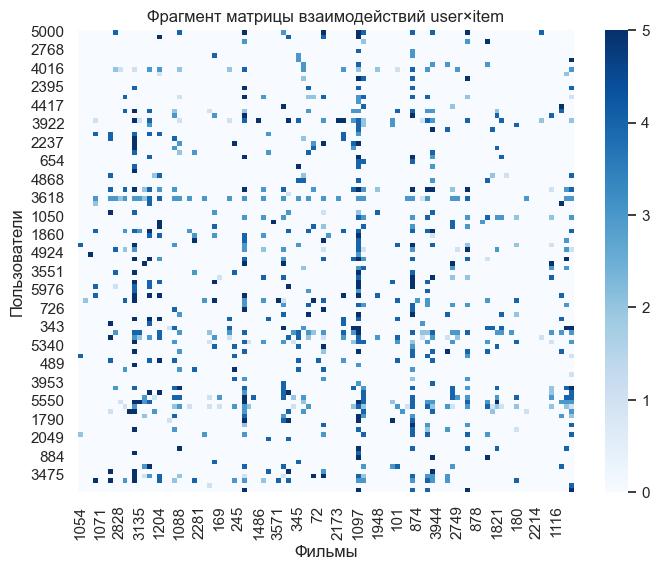

In [56]:
sample_users = ratings['user_id'].sample(2000, random_state=42)
sample = ratings[ratings['user_id'].isin(sample_users)]

pivot = sample.pivot(index='user_id', columns='movie_id', values='rating').fillna(0)

plt.figure(figsize=(8,6))
sns.heatmap(pivot.sample(100, axis=0).sample(100, axis=1), cmap='Blues')
plt.title("Фрагмент матрицы взаимодействий user×item")
plt.xlabel("Фильмы")
plt.ylabel("Пользователи")
plt.show()

Матрица взаимодействий является крайне разреженной (≈99.9%). Это ключевая проблема рекомендательных систем и основной аргумент в пользу факторизационных моделей (ALS/BPR) и имплицитных подходов.

#### 11. Анализ холодного старта

In [58]:
cold_users_share = (user_activity['user_ratings'] < 5).mean()
cold_items_share = (item_activity['movie_ratings'] < 5).mean()

cold_users_share, cold_items_share

(np.float64(0.0), np.float64(0.07825148407987048))

В данных практически отсутствуют cold users, ни один пользователь не поставил меньше 5 оценок. Это связано с тем, что MovieLens изначально собирает активную аудиторию, поэтому проблема холодного старта для пользователей выражена слабо.

С другой стороны, около 7.9% фильмов имеют меньше 5 оценок,это холодные элементы. Для них модель будет иметь недостаточно информации, что усложняет обучение, особенно для коллаборативных методов. Таким образом, проблема холодного старта существует в первую очередь для фильмов, и в проде её обычно решают контентными признаками (жанры, описание, год и тд) или гибридными моделями.

## Финальный вывод по EDA-анализу

Анализ данных MovieLens-1M выявил несколько важных свойств пользовательских оценок и структуры взаимодействий, критичных для построения рекомендательных систем.

1. Распределение активности пользователей и фильмов
   - Распределения имеют выраженный heavy-tail (long-tail) характер: большинство пользователей ставят мало оценок, а небольшая доля ставит сотни и тысячи. Аналогичная картина наблюдается по фильмам.
   - Это подтверждает высокую разреженность матрицы взаимодействий, характерную для рекомендательных систем.

2. Разреженность
   - Пользователь-фильм матрица заполнена менее чем на 0.1%, что делает обучение напрямую на dense-матрицах неэффективным и указывает на необходимость использования факторизационных и implicit-подходов.

3. Распределение рейтингов
   - Рейтинги смещены в сторону высоких значений (мода = 4, медиана = 4, среднее ≈ 3.58).
   - Это отражает позитивный рейтинговый bias, типичный для формата «пользователь ставит оценку любимому контенту».

4. Временная динамика
   - Активность пользователей меняется во времени и по временным паттернам (день недели / час суток).
   - Это указывает на временную структуру данных и важность корректного time-based split для предотвращения data leakage.

5. Жанровые предпочтения
   - Наиболее массовые жанры по объёму: Comedy и Drama.
   - Наиболее высоко оцениваемые жанры: Film-Noir, Documentary, War, что говорит о различных сценариях востребованности (популярность ≠ качество).

6. Холодный старт
   - Проблема выражена преимущественно для фильмов: ~8% имеют <5 оценок.
   - Для пользователей проблема практически отсутствует.
   - Для продовых систем это аргумент в пользу гибридных моделей (контент + коллаборатив).

### Итог
Данные обладают классическими свойствами реального рекомендательного сценария:
- extreme sparsity
- long-tail распределения
- жанровая неоднородность
- временные паттерны
- частичная проблема cold-start

Эти свойства подтверждают релевантность применения ALS/BPR, implicit feedback-моделей и последующего ранжирования, а также создают пространство для улучшений за счёт контентных признаков.